## Flexible Electrode Probe Geometry: 

Create a flat 2D probe as well as a modified probe based on curvature during bundle process. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from probeinterface import Probe
from probeinterface.plotting import plot_probe
from probeGeom import create_flat_geom

In [2]:
num_contact_sites = 64

y_flat_contact_dist = 40 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)

final_probe_width = 80 # um

(<matplotlib.collections.PolyCollection at 0x115803d50>,
 <matplotlib.collections.PolyCollection at 0x11583d950>)

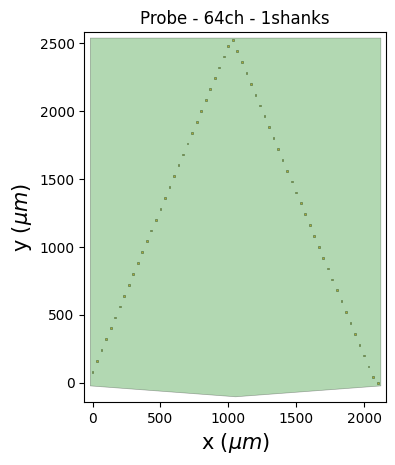

In [4]:
positions = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)

probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=positions, shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
probe.create_auto_shape()

plot_probe(probe)

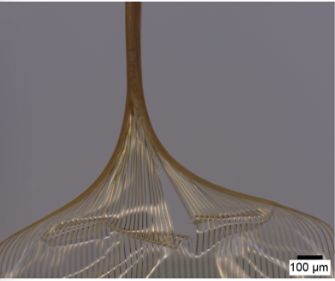

Goal: modify contact site x- and y-coordinate sites as a smooth function of the flat x-coordinates

Idea: Base is fixed and wires are drawn towards the center into a bundle 
- wires near the center stay almost in place (maintain their x- and y-coord values / effective change is small or zero)
- wires near edges bend more so they are shortened (distance between y coords increases as we sweep from center to outer wires). these wires at the edge also have a greater delta_x coord value than those at the center. 

We will use the idea of wire curves to model the transformation 
- each electrode wire will be represented as a continuous spatial curve with contact sites as endpoints of these curves 
- this is different from assigning each contact site a new position independently via an arbitrary transformation 

each wire contributes exactly one point but that point is constrained by a curve geometry 

we will define
- curvature of the wires
- bundle convergence
- relative bending of the edge vs center wires
- how much if any crossings occur / noise stochasticity 


"In our setup, each contact site is located at the tip of a flexible wire.
Instead of assigning contact positions directly through an arbitrary transformation, we model each wire as a continuous curve and define the contact location as the endpoint of that curve.

This ensures that the resulting geometry reflects physically plausible deformations of the probe, such as bending and bundling, rather than independent movement of points.

Compared to a purely mathematical transformation, this approach preserves the structural relationship between contacts and allows us to model effects like curvature and wire crossings in a controlled and interpretable way."

***

Params to specify:

1. number of wires N 
2. flat contact (original) contact positions (xi_flat, yi_flat)
3. final bundle width (target lateral compression)
4. lef-right compression function: maps flat x position to bundled lateral endpoint 
5. shape function for x bending 
6. noise that makes sense with wire-to-wire correlation maybe call it a disorder parameter 
7. make sure monotonicity in y (wires don't fold back on themselves)

***

Questions left to specify: 
-  tip is loose but theres a fixed side (define the part where the curve is being shifted)
-  is y measured from bundle or from flat contact plane 

***

***

***
***
Assumptions: 
- wires are very long / bundle motion is happened at a location / depth such that its location doesn't impact things: we go from wires that are vertical / straight lines to those that have two vertical bits separated by a smooth curve 
- all wires are fixed at one end and only there 
- as of right now, it's a 2D thing 

for one wire:
inputs:
- x0, y0, final bundle width 

outputs:
- final horizontal tip position 
- final vertical tip position 

1. compute final horizontal position given W0 and Wf (after bundling) 
   - each wire is compressed towards the center by the same scale factor s = Wf/W0. xf = sx0 (this is the simplest assumption, monotnoicity/no crossing, symmetry) **could try a tanh for a harder boundary bundle 
   - later model this more 3D such that we allow for wires to subtly cross or noise etc
   - delta_x = xf - x0 
2. choose a smooth curve shape
   - x(t) = x0 + deltax(3t^2 - 2t^3), t in [0, 1]
   - y(t) = y0 - Ht 
   - t=0 is the start of bent region, t=1 is the tip end of bent region, H is the total vertical drop across bent region 
   - so at the end, yf = y0 - H
3. determine the vertical extend of spline and subtract from the y0
   - wire has fixed length, curve bends sideways by delta_x, this causes some arc length which decreases our vertical reach and determines our final y-coordinate

In [5]:
# determining the spline function 

# let x(t) define the horizontal position of the wire as we move from the start of the bend to the tip (the vertical position goes from our original to the final bundle position) 
# t = 0 is the start of the bend and t=1 is the tip 

# we want x(0) = x0 and x(1) = xf = x0 + delta_x
# x(t) = x0 + delta_x * S(t) where S(0) = 0 and S(1) = 1 

# S is the amount of horizontal motion completed at time t 
# we want vertical tangents at both ends so S'(0) = 0 and S'(1) = 0
# the simplest function to satify this is a polynomial. We have 4 constraints so n+1 coefficients, n=3 is a cubic polynomial: S(t) = a*t^3 + b*t^2 + c*t + d

# we solve for our constraints and get S(t) = 2*t^3 - 3*t^2

Determining the final y-coord:

yf = y0 - H (with H = height lost in the curve) 

the y coordinates also trace a curve y(t) = y0 - Ht

original wire length was y0 

L = integral from 0 to 1 of sqrt((dx/dt)^2 + (dy/dt^2)) dt

we enfore that L = y0 

dx/dt = deltaxS'(t) 
dy/dt = -H 

so we enforce that the integral from 0 to 1 is the sqrt((deltax * S'(t))^2 + H^2)dt = y0 

and now we solve for H. 

S'(t) = 6t(1-t) 

there's no closed form solution, so we mmust solve it numerically 

In [6]:
# don't plot inline

%matplotlib qt # inline or qt 

UsageError: unrecognized arguments: # inline or qt


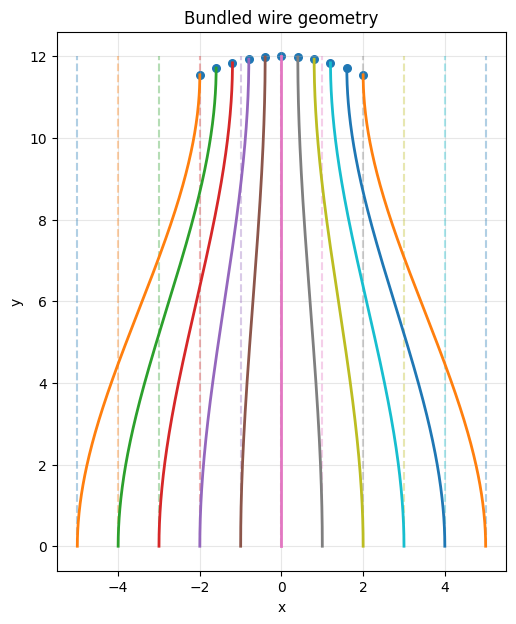

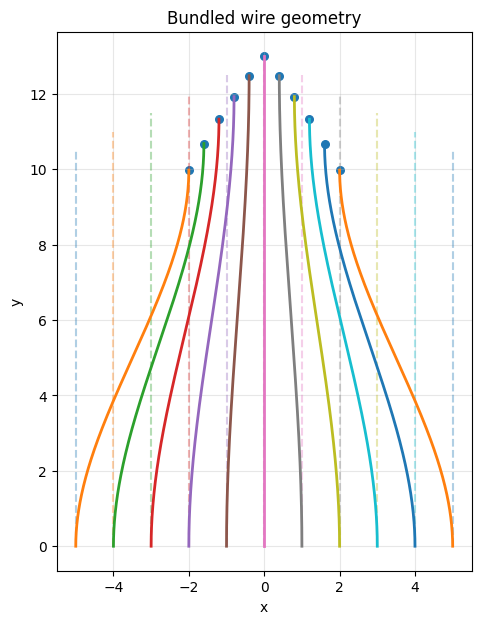

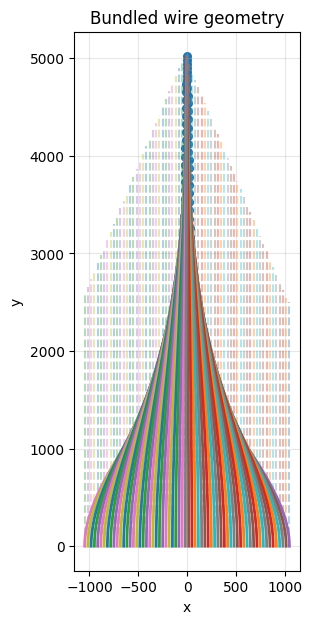

In [ ]:
from probeGeom import plot_bundle

# Example 1: equally spaced wires, equal lengths
x0 = np.linspace(-5, 5, 11)
length = 12.0
final_bundle_width = 4.0

fig, ax, xf, yf = plot_bundle(
    x0=x0,
    length=length,
    final_bundle_width=final_bundle_width,
    show_original=True,
)
plt.show()

# Example 2: variable wire lengths
lengths = np.array([10.5, 11, 11.5, 12, 12.5, 13, 12.5, 12, 11.5, 11, 10.5]) 

fig, ax, xf, yf = plot_bundle(
    x0=x0,
    length=lengths,
    final_bundle_width=4.0,
    show_original=True,
)
plt.show()

    # Example 3: our probe 
base_length = 2500.0  # choose something comfortably larger than the max y offset

lengths = positions[:, 1] + base_length
x0 = positions[:, 0] - np.mean(positions[:, 0])

fig, ax, xf, yf = plot_bundle(
    x0=x0,
    length=lengths,
    final_bundle_width=80.0,
    show_original=True,
)
plt.show()

(<matplotlib.collections.PolyCollection at 0x115903d50>,
 <matplotlib.collections.PolyCollection at 0x127c4c9d0>)

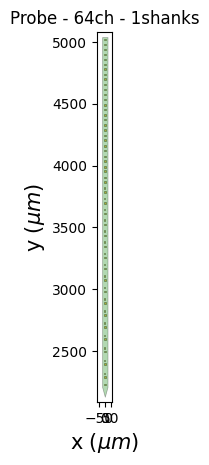

In [ ]:
base_length = 2500.0  # choose something comfortably larger than the max y offset

lengths = positions[:, 1] + base_length
x0 = positions[:, 0] - np.mean(positions[:, 0])

xf, yf = bundle_tip_positions(
        x0=x0,
        length=lengths,
        final_bundle_width=final_bundle_width,
        initial_width=None,
    )

probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=np.column_stack((xf, yf)), shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
probe.create_auto_shape()

plot_probe(probe)



In [ ]:
from dataLoading_utils import buildProbeJSON_modifiedCoords

amplifier_xml_path = ...
xcoords = xf
ycoords = yf
output_filename = ...

buildProbeJSON_modifiedCoords(amplifier_xml_path, xcoords, ycoords, output_filename, dorsalVentralOrder=False)


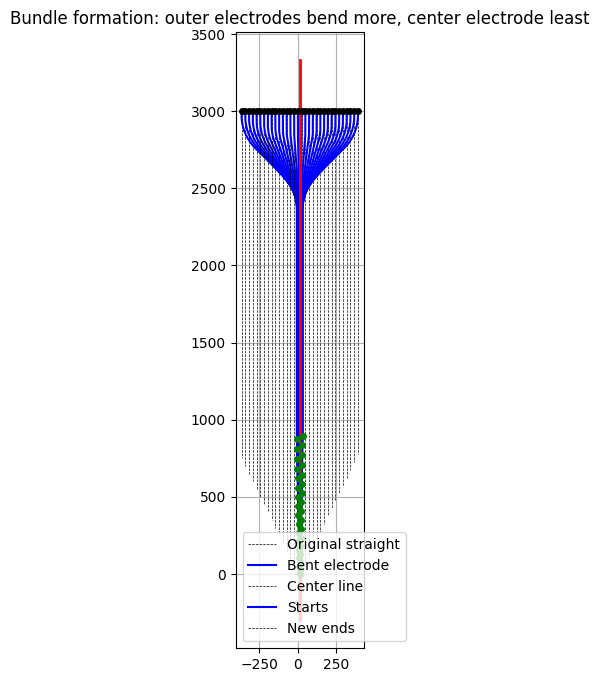

New bent endpoints:
[[-6.87500000e+00  8.72729962e+02]
 [-5.65725806e+00  8.08143342e+02]
 [-4.43951613e+00  7.44412530e+02]
 [-3.22177419e+00  6.81545731e+02]
 [-2.00403226e+00  6.19553039e+02]
 [-7.86290323e-01  5.58446430e+02]
 [ 4.31451613e-01  4.98239762e+02]
 [ 1.64919355e+00  4.38948799e+02]
 [ 2.86693548e+00  3.80591241e+02]
 [ 4.08467742e+00  3.23186773e+02]
 [ 5.30241935e+00  2.66757124e+02]
 [ 6.52016129e+00  2.11326147e+02]
 [ 7.73790323e+00  1.56919905e+02]
 [ 8.95564516e+00  1.03566780e+02]
 [ 1.01733871e+01  5.12975918e+01]
 [ 1.13911290e+01  1.45741710e-01]
 [ 1.26088710e+01  2.51457417e+01]
 [ 1.38266129e+01  7.62975918e+01]
 [ 1.50443548e+01  1.28566780e+02]
 [ 1.62620968e+01  1.81919905e+02]
 [ 1.74798387e+01  2.36326147e+02]
 [ 1.86975806e+01  2.91757124e+02]
 [ 1.99153226e+01  3.48186773e+02]
 [ 2.11330645e+01  4.05591241e+02]
 [ 2.23508065e+01  4.63948799e+02]
 [ 2.35685484e+01  5.23239762e+02]
 [ 2.47862903e+01  5.83446430e+02]
 [ 2.60040323e+01  6.44553039e+02]


In [1]:
from convert_bending_model import run_from_mat_file

result = run_from_mat_file("matlab.mat", make_plot=True)

In [ ]:
#bundleRatio = 0.05;   % endpoint offset after bending = 25% of original offset


#a bundleRatio = 0.05 means the final offset is 5% of the original, not 25%.

#So either:

#the value should be 0.25, or
#the comment is wrong.


[[-6.87500000e+00  8.72729962e+02]
 [-5.65725806e+00  8.08143342e+02]
 [-4.43951613e+00  7.44412530e+02]
 [-3.22177419e+00  6.81545731e+02]
 [-2.00403226e+00  6.19553039e+02]
 [-7.86290323e-01  5.58446430e+02]
 [ 4.31451613e-01  4.98239762e+02]
 [ 1.64919355e+00  4.38948799e+02]
 [ 2.86693548e+00  3.80591241e+02]
 [ 4.08467742e+00  3.23186773e+02]
 [ 5.30241935e+00  2.66757124e+02]
 [ 6.52016129e+00  2.11326147e+02]
 [ 7.73790323e+00  1.56919905e+02]
 [ 8.95564516e+00  1.03566780e+02]
 [ 1.01733871e+01  5.12975918e+01]
 [ 1.13911290e+01  1.45741710e-01]
 [ 1.26088710e+01  2.51457417e+01]
 [ 1.38266129e+01  7.62975918e+01]
 [ 1.50443548e+01  1.28566780e+02]
 [ 1.62620968e+01  1.81919905e+02]
 [ 1.74798387e+01  2.36326147e+02]
 [ 1.86975806e+01  2.91757124e+02]
 [ 1.99153226e+01  3.48186773e+02]
 [ 2.11330645e+01  4.05591241e+02]
 [ 2.23508065e+01  4.63948799e+02]
 [ 2.35685484e+01  5.23239762e+02]
 [ 2.47862903e+01  5.83446430e+02]
 [ 2.60040323e+01  6.44553039e+02]
 [ 2.72217742e+01  7

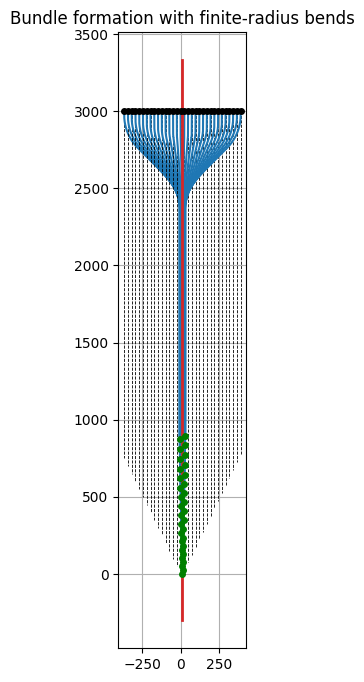

In [3]:
from clean_bending_model import run_from_mat_file, BundleParameters

params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.05,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_mat_file("matlab.mat", params=params, make_plot=True)

print(result.ends)
print(result.bend_angles_deg)
print(result.middle_segment_lengths)